In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label
import pandas as pd
import matplotlib.dates as mdates

In [5]:
# Define file paths
desired_ensemble_member = '008'
desired_AMOC_state = '1301'

# Determine the bmb regime 
if desired_ensemble_member <= '010':
    bmb = 'cmip6'
else:
    bmb = 'smbb'

hist_file = f'/data2/michsh/ET_os_calculated/{desired_AMOC_state}/{desired_ensemble_member}/BHIST{bmb}_LE2-{desired_AMOC_state}.{desired_ensemble_member}_ETos_daily.nc'
ssp_file = f'/data2/michsh/ET_os_calculated/{desired_AMOC_state}/{desired_ensemble_member}/BSSP370{bmb}_LE2-{desired_AMOC_state}.{desired_ensemble_member}_ETos_daily.nc'

# DIAGNOSTICS + ZARR FILE TRANSFORMATION

In [6]:
# Define the plot bounds 
s_lat = 24
n_lat = 52
w_lon = -125
e_lon = -67

# Bound for the upper midwest, or the subplot within the larger CONUS plot
sub_s_lat = 39
sub_n_lat = 49
sub_w_lon = -104
sub_e_lon = -89

datasets = [hist_file, ssp_file]

for dataset in datasets: 

    # Open the datasets 
    ds = xr.open_dataset(dataset, engine='netcdf4')
    print(f"Opened dataset: {dataset}")

    # West lon coordinate adjustments for both CONUS and upper midwest bounds 
    if ds['lon'].max() > 180 and w_lon < 0:
        actual_w_lon = w_lon + 360  
    else:
        actual_w_lon = w_lon

    if ds['lon'].max() > 180 and sub_w_lon < 0:
        actual_sub_w_lon = sub_w_lon + 360
    else:
        actual_sub_w_lon = sub_w_lon

    # East lon coordinate adjustments for both CONUS and upper midwest bounds 
    if ds['lon'].max() > 180 and e_lon < 0:
        actual_e_lon = e_lon + 360  
    else:
        actual_e_lon = e_lon

    if ds['lon'].max() > 180 and sub_e_lon < 0:
        actual_sub_e_lon = sub_e_lon + 360  
    else:
        actual_sub_e_lon = sub_e_lon

    # Determines which way the coords are dispayed in the array and aligns them properly
    if ds['lat'].values[0] > ds['lat'].values[-1]:
        lat_slice = slice(n_lat, s_lat)  
        sub_lat_slice = slice(sub_n_lat, sub_s_lat)
    else:
        lat_slice = slice(s_lat, n_lat)  
        sub_lat_slice = slice(sub_s_lat, sub_n_lat)

    # Get rid of overlapping time values and reset time dimension
    time_vals_h = ds['time'].values
    _, idx_h = np.unique(time_vals_h, return_index=True)
    ds = ds.isel(time=idx_h)

    # Slice spatially by CONUS and upper midwest bounds
    ds_CONUS = ds['ET_os'].sel(lat=lat_slice, lon=slice(actual_w_lon, actual_e_lon))
    ds_subregion = ds['ET_os'].sel(lat=sub_lat_slice, lon=slice(actual_sub_w_lon, actual_sub_e_lon))

    # Make sure the file is not corrupt 
    if ds_CONUS.size == 0:
        print(f"Error: Slicing resulted in an empty dataset.")
        print(f"Dataset Lat Range: {float(ds_CONUS['lat'].min())} to {float(ds_CONUS['lat'].max())}")
        print(f"Dataset Lon Range: {float(ds_CONUS['lon'].min())} to {float(ds_CONUS['lon'].max())}")

    if ds_subregion.size == 0:
        print(f"Error: Slicing resulted in an empty dataset.")
        print(f"Dataset Lat Range: {float(ds_subregion['lat'].min())} to {float(ds_subregion['lat'].max())}")
        print(f"Dataset Lon Range: {float(ds_subregion['lon'].min())} to {float(ds_subregion['lon'].max())}")

    # Weight the upper midwest subregion by the cosine of the latitude
    ds_weights = np.cos(np.deg2rad(ds_subregion['lat']))
    ds_weights.name = "weights"

    if dataset == hist_file:

        # ============== CONUS REGION ==============

        hist_mean = ds_CONUS.mean(dim='time').compute()
        hist_75th = ds_CONUS.quantile(0.75, dim='time').compute()
        hist_90th = ds_CONUS.quantile(0.9, dim='time').compute()
        hist_99th = ds_CONUS.quantile(0.99, dim='time').compute()

        # ============= SUBREGION: UPRMIDWST =============

        # Calculate the spatial weighted average of the historic dataset
        hist_avg = ds_subregion.weighted(ds_weights).mean(dim=['lat', 'lon']).load()

        # Clip negative values to 0
        hist_replaced = int((hist_avg < 0).sum())
        hist_zeroed_avg = hist_avg.clip(min=0)
        print(f'This code replaced negative values with 0 in the HIST dataset: {hist_replaced} instances.')

        # Extract the max value, the max timestamp, and the integer index (time step) of that max value
        h_max, h_max_time, time_step_max = float(hist_zeroed_avg.max()), hist_zeroed_avg.idxmax().values, int(hist_zeroed_avg.argmax())
        h_min, h_min_time, time_step_min = float(hist_zeroed_avg.min()), hist_zeroed_avg.idxmin().values, int(hist_zeroed_avg.argmin())

        print("\n" + "="*50)
        print("GRID-AVERAGED 150-YEAR MAX/MIN VALUE REPORT")
        print("="*50)
        print(f"Maximum Spatially Averaged ET_os Value: {h_max:.4f} mm/day")
        print(f"Associated Timestamp and Time Step: {h_max_time}, {time_step_max}")
        print(f"Minimum Spatially Averaged ET_os Value: {h_min:.4f} mm/day")
        print(f"Associated Timestamp and Time Step: {h_min_time}, {time_step_min}")
        print("="*50 + "\n")

    else:

        # ============== CONUS REGION ==============

        ftr_mean = ds_CONUS.mean(dim='time').compute()
        ftr_75th = ds_CONUS.quantile(0.75, dim='time').compute()
        ftr_90th = ds_CONUS.quantile(0.9, dim='time').compute()
        ftr_99th = ds_CONUS.quantile(0.99, dim='time').compute()

        # ============= SUBREGION: UPRMIDWST =============

        # Calculate the spatial weighted average of the SSP dataset
        ssp_avg = ds_subregion.weighted(ds_weights).mean(dim=['lat', 'lon']).load()

        # Clip negative values to 0
        ssp_replaced = int((ssp_avg < 0).sum())
        ssp_zeroed_avg = ssp_avg.clip(min=0)
        print(f'This code replaced negative values with 0 in the SSP dataset: {ssp_replaced} instances.')

        # Extract the max value, the max timestamp, and the integer index (time step) of that max value
        s_max, s_max_time, time_step_max = float(ssp_zeroed_avg.max()), ssp_zeroed_avg.idxmax().values, int(ssp_zeroed_avg.argmax())
        s_min, s_min_time, time_step_min = float(ssp_zeroed_avg.min()), ssp_zeroed_avg.idxmin().values, int(ssp_zeroed_avg.argmin())

        print("\n" + "="*50)
        print("GRID-AVERAGED 150-YEAR MAX/MIN VALUE REPORT")
        print("="*50)
        print(f"Maximum Spatially Averaged ET_os Value: {s_max:.4f} mm/day")
        print(f"Associated Timestamp and Time Step: {s_max_time}, {time_step_max}")
        print(f"Minimum Spatially Averaged ET_os Value: {s_min:.4f} mm/day")
        print(f"Associated Timestamp and Time Step: {s_min_time}, {time_step_min}")
        print("="*50 + "\n")

# Calculates Delta of ET_os between the SSP and HIST datasets for the CONUS region
delta_mean = ftr_mean - hist_mean
delta_75th = ftr_75th - hist_75th
delta_90th = ftr_90th - hist_90th
delta_99th = ftr_99th - hist_99th

print('Ready for plotting!')

Opened dataset: /data2/michsh/ET_os_calculated/1301/008/BHISTcmip6_LE2-1301.008_ETos_daily.nc


This code replaced negative values with 0 in the HIST dataset: 0 instances.

GRID-AVERAGED 150-YEAR MAX/MIN VALUE REPORT
Maximum Spatially Averaged ET_os Value: 15.9913 mm/day
Associated Timestamp and Time Step: 1868-07-05 00:00:00, 3947
Minimum Spatially Averaged ET_os Value: 0.8630 mm/day
Associated Timestamp and Time Step: 1960-04-05 00:00:00, 23544

Opened dataset: /data2/michsh/ET_os_calculated/1301/008/BSSP370cmip6_LE2-1301.008_ETos_daily.nc
This code replaced negative values with 0 in the SSP dataset: 0 instances.

GRID-AVERAGED 150-YEAR MAX/MIN VALUE REPORT
Maximum Spatially Averaged ET_os Value: 18.6218 mm/day
Associated Timestamp and Time Step: 2090-08-15 00:00:00, 16186
Minimum Spatially Averaged ET_os Value: 1.0798 mm/day
Associated Timestamp and Time Step: 2031-10-31 00:00:00, 3637

Ready for plotting!


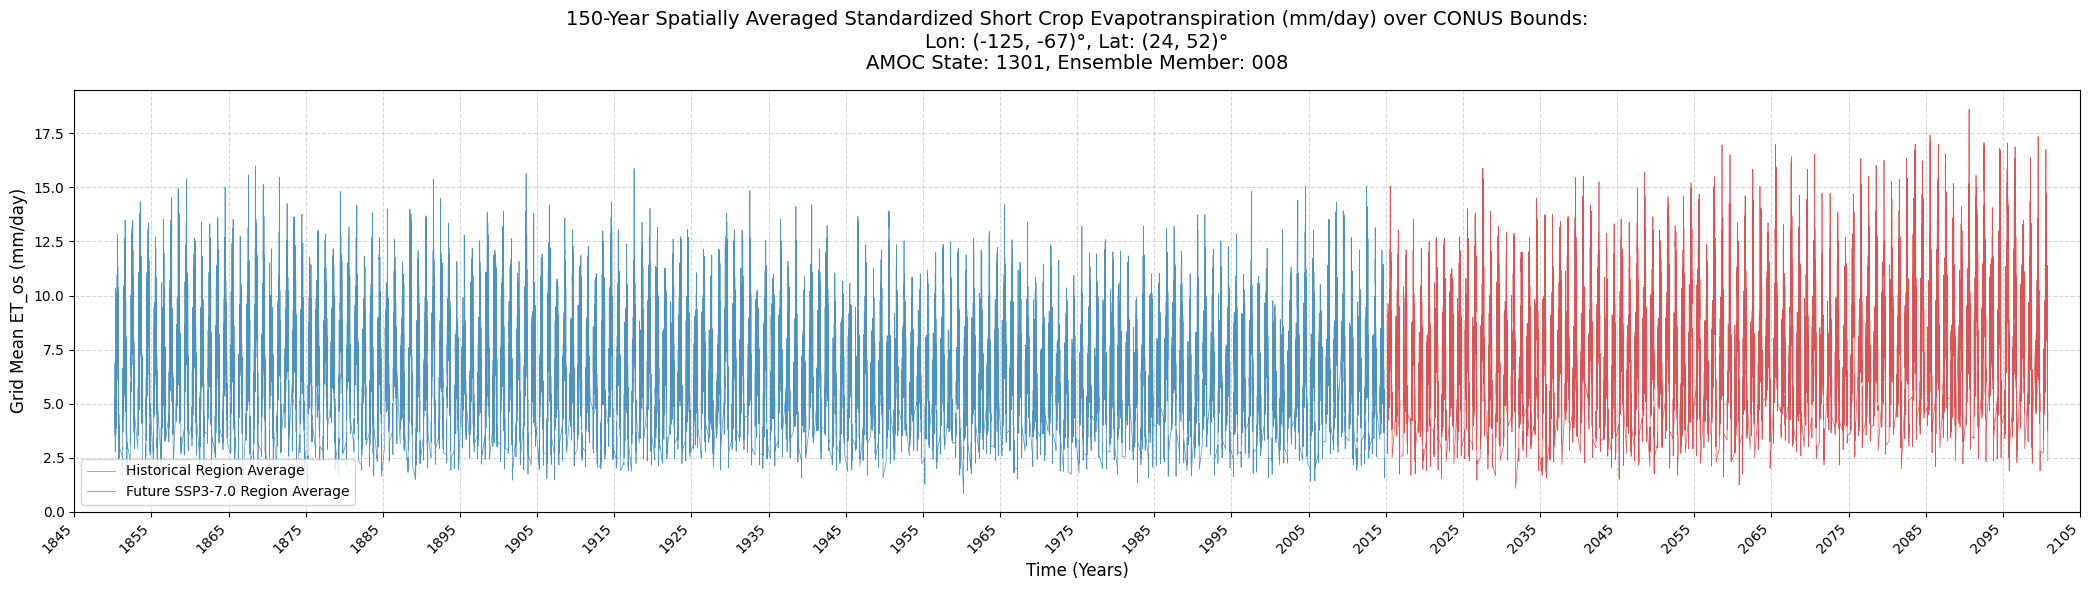

In [7]:
fig, ax = plt.subplots(figsize=(21, 6))

hist_avg.plot(ax=ax, linewidth=0.5, color='tab:blue', alpha=0.8, label='Historical Region Average')
ssp_avg.plot(ax=ax, linewidth=0.5, color='tab:red', alpha=0.8, label='Future SSP3-7.0 Region Average')

plt.title(f"150-Year Spatially Averaged Standardized Short Crop Evapotranspiration (mm/day) over CONUS Bounds:\nLon: ({w_lon}, {e_lon})°, Lat: ({s_lat}, {n_lat})°\nAMOC State: {desired_AMOC_state}, Ensemble Member: {desired_ensemble_member}", fontsize=14, pad=15)
plt.ylabel("Grid Mean ET_os (mm/day)", fontsize=12)
plt.xlabel("Time (Years)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(bottom=0)

# --- INTEGRATED SOLUTION FOR NETCDF CALENDARS ---
calendar_type = hist_avg.time.dt.calendar

# Build explicit calendar-compliant datetime objects for boundaries
start_date = cftime.datetime(1850, 1, 1, calendar=calendar_type)
end_date = cftime.datetime(2100, 12, 31, calendar=calendar_type)
ax.set_xlim(start_date, end_date)

# Generate explicit 10-year tick markers compatible with cftime axes
tick_years = list(range(1845, 2106, 10))
tick_positions = [cftime.datetime(yr, 1, 1, calendar=calendar_type) for yr in tick_years]
tick_labels = [str(yr) for yr in tick_years]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

# Rotate labels slightly so they don't overlap
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

<xarray.Dataset> Size: 8GB
Dimensions:    (lat: 192, lon: 288, time: 35310)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 282kB 1850-04-01 00:00:00 ... 2014-10-31 00:00:00
Data variables:
    ET_os      (time, lat, lon) float32 8GB ...
    dayofyear  (time) int64 282kB 91 92 93 94 95 96 ... 299 300 301 302 303 304

In [7]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.ndimage import label

def analyze_thirstwaves_detailed(ds_series, threshold_series):
    """
    Analyzes a 1D time series and returns a day-by-day xarray Dataset 
    containing ET_os, daily thirstwave flags, event intensity, event duration,
    and annual event frequency.
    """
    # Initialize empty arrays matching the original time series length
    time_coords = ds_series["time"].values
    total_days = len(time_coords)
    
    is_thirstwave = np.zeros(total_days, dtype=np.int8)
    tw_intensity = np.zeros(total_days, dtype=np.float32)
    tw_duration = np.zeros(total_days, dtype=np.float32)
    tw_annual_freq = np.zeros(total_days, dtype=np.int32)
    
    years = np.unique(ds_series["time.year"].values)
    
    for year in years:
        # Find indices in the master array belonging to the current year
        year_mask = ds_series["time.year"] == year
        year_indices = np.where(year_mask)[0]
        
        # Isolate the year's data
        year_ds = ds_series.isel(time=year_indices)
        
        # Filter for Growing Season (Months 4 through 10)
        gs_mask = (year_ds["time.month"] >= 4) & (year_ds["time.month"] <= 10)
        gs_indices_inside_year = np.where(gs_mask)[0]
        
        # Absolute indices in the master time array for this year's growing season
        master_gs_indices = year_indices[gs_indices_inside_year]
        
        growing_season = year_ds.isel(time=gs_indices_inside_year)
        
        if len(growing_season) == 0:
            continue
            
        # Extract and map thresholds
        day_of_years = np.clip(growing_season["time.dayofyear"].values, 1, 365)
        year_threshold = threshold_series.sel(dayofyear=day_of_years).values
        
        # Calculate daily anomalies
        anomaly = growing_season.values - year_threshold
        exceeded_mask = anomaly > 0
        
        # Identify discrete consecutive events
        labeled_events, num_features = label(exceeded_mask)
        
        # Map annual frequency to every day belonging to this year
        tw_annual_freq[year_mask] = num_features
        
        if num_features == 0:
            continue
            
        # Process each individual event within the growing season
        for event_id in range(1, num_features + 1):
            event_mask_gs = (labeled_events == event_id)
            
            # Map event properties back to the master array indices
            event_master_indices = master_gs_indices[event_mask_gs]
            
            # Duration of this explicit event
            duration_days = np.sum(event_mask_gs)
            
            # Mean intensity (anomaly magnitude) of this explicit event
            mean_intensity = np.mean(anomaly[event_mask_gs])
            
            # Write to arrays using master timeline indices
            is_thirstwave[event_master_indices] = 1
            tw_duration[event_master_indices] = duration_days
            tw_intensity[event_master_indices] = mean_intensity

    # Combine all compiled arrays into a structured xarray Dataset
    output_ds = xr.Dataset(
        data_vars={
            'ET_os': (['time'], ds_series.values),
            'is_thirstwave': (['time'], is_thirstwave),
            'thirstwave_intensity': (['time'], tw_intensity),
            'thirstwave_duration': (['time'], tw_duration),
            'thirstwave_annual_frequency': (['time'], tw_annual_freq)
        },
        coords={
            'time': time_coords
        }
    )
    
    return output_ds

# --- Run the Analysis ---

# 1. Compute your seasonal 90th percentile curve from historical data
historical_threshold = hist_zeroed_avg.groupby("time.dayofyear").quantile(0.9, dim="time")

# 2. Process historical timeline into a detailed daily tracking Dataset
print("Processing detailed historical metrics...")
hist_detailed_ds = analyze_thirstwaves_detailed(hist_zeroed_avg, historical_threshold)

# 3. Process future timeline into a detailed daily tracking Dataset (using the historical benchmark)
print("Processing detailed future metrics...")
ssp_detailed_ds = analyze_thirstwaves_detailed(ssp_zeroed_avg, historical_threshold)

# --- Save Options ---
# Chunking the datasets makes them Zarr-compliant and optimized for time series looks
hist_detailed_ds = hist_detailed_ds.chunk({'time': -1})
ssp_detailed_ds = ssp_detailed_ds.chunk({'time': -1})

# Exporting directly to Zarr stores
hist_detailed_ds.to_zarr("/data1/michsh/zarr_files/historical_thirstwave_time_series.zarr", mode='w', consolidated=True)
ssp_detailed_ds.to_zarr("/data1/michsh/zarr_files/future_thirstwave_time_series.zarr", mode='w', consolidated=True)

print("Tracking complete. Detailed daily logs saved to Zarr archives!")

Processing detailed historical metrics...
Processing detailed future metrics...
Tracking complete. Detailed daily logs saved to Zarr archives!


/tmp/ipykernel_2019217/4115568086.py:16: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_index = detailed_ds.indexes['time'].to_datetimeindex()


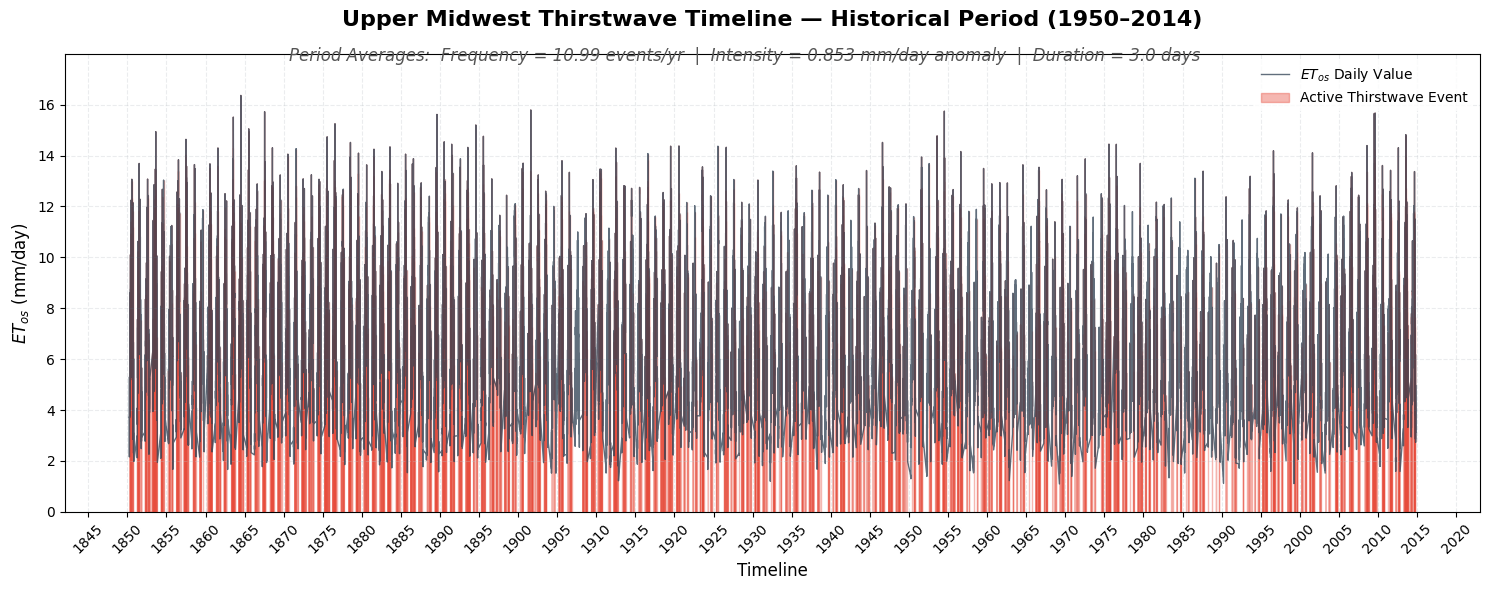

/tmp/ipykernel_2019217/4115568086.py:16: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_index = detailed_ds.indexes['time'].to_datetimeindex()


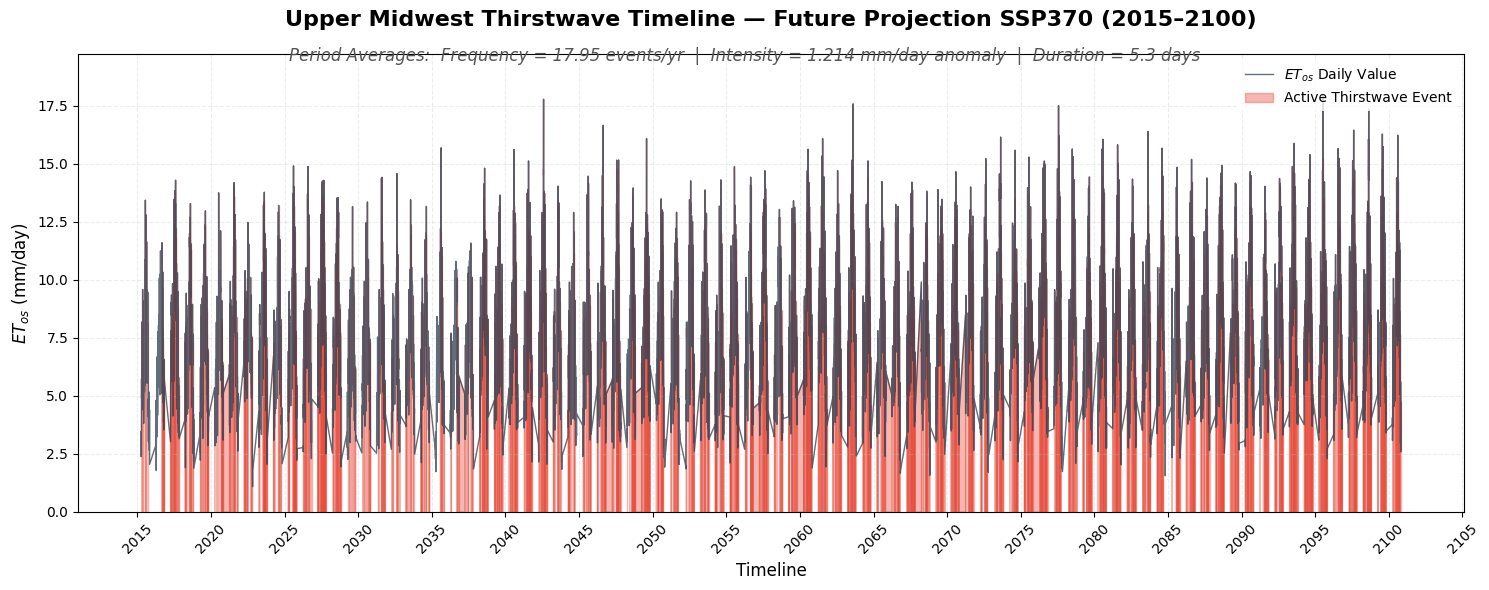

In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_thirstwave_timeline(detailed_ds, title_period_name):
    """
    Plots a continuous timeline of ET_os and highlights active thirstwaves,
    displaying mean period metrics (Frequency, Intensity, Duration).
    Handles non-leap climate calendars seamlessly.
    """
    # 1. Cleanly convert cftime (DatetimeNoLeap) to standard pandas datetime
    try:
        # Xarray's built-in converter for climate calendars
        time_index = detailed_ds.indexes['time'].to_datetimeindex()
        time = pd.to_datetime(time_index)
    except AttributeError:
        # Fallback if it is already standard or partially converted
        time = pd.to_datetime(detailed_ds['time'].values)
        
    et_os = detailed_ds['ET_os'].values
    is_tw = detailed_ds['is_thirstwave'].values
    
    # 2. Calculate Period-Wide Summary Metrics
    # Grab one unique frequency value per year to find the true period average.
    years, unique_indices = np.unique(time.year, return_index=True)
    mean_freq = detailed_ds['thirstwave_annual_frequency'].values[unique_indices].mean()
    
    # Intensity and Duration are only averaged on days when a thirstwave actually happens.
    tw_days_mask = is_tw == 1
    
    if np.any(tw_days_mask):
        mean_intensity = detailed_ds['thirstwave_intensity'].values[tw_days_mask].mean()
        mean_duration = detailed_ds['thirstwave_duration'].values[tw_days_mask].mean()
    else:
        mean_intensity = 0.0
        mean_duration = 0.0

    # 3. Initialize the Plot
    fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
    
    # Plot the continuous baseline daily ET_os line
    ax.plot(time, et_os, color='#2c3e50', linewidth=1, alpha=0.75, label='$ET_{os}$ Daily Value')
    
    # 4. Highlight thirstwave periods using fill_between
    ax.fill_between(time, 0, et_os, where=(is_tw == 1), 
                    color='#e74c3c', alpha=0.4, label='Active Thirstwave Event')
    
    # 5. Styling and Labels
    ax.set_title(f"Upper Midwest Thirstwave Timeline — {title_period_name}", fontsize=16, pad=20, weight='bold')
    
    # Subtitle displaying the mean characteristics
    subtitle_text = (f"Period Averages:  "
                     f"Frequency = {mean_freq:.2f} events/yr  |  "
                     f"Intensity = {mean_intensity:.3f} mm/day anomaly  |  "
                     f"Duration = {mean_duration:.1f} days")
    
    fig.text(0.5, 0.89, subtitle_text, ha='center', fontsize=12, color='#555555', style='italic')
    
    ax.set_ylabel("$ET_{os}$ (mm/day)", fontsize=12)
    ax.set_xlabel("Timeline", fontsize=12)
    
    # Handle X-Axis formatting beautifully across long multi-year blocks
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5)) # Ticks every 5 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    
    ax.grid(True, linestyle='--', alpha=0.3, color='#bdc3c7')
    ax.set_ylim(0, np.max(et_os) * 1.1) # Give some space at the top of the plot
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    plt.tight_layout()
    return fig, ax

# --- Example Execution Calls ---

# 1. Plot Historical Period
fig_hist, ax_hist = plot_thirstwave_timeline(hist_detailed_ds, "Historical Period (1950–2014)")
plt.savefig("/data1/michsh/txt_files/historical_thirstwave_timeline.png", bbox_inches='tight')
plt.show()

# 2. Plot Future Period
fig_ssp, ax_ssp = plot_thirstwave_timeline(ssp_detailed_ds, "Future Projection SSP370 (2015–2100)")
plt.savefig("/data1/michsh/txt_files/future_thirstwave_timeline.png", bbox_inches='tight')
plt.show()

/tmp/ipykernel_2019217/2697095282.py:8: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_index = future_ds.indexes['time'].to_datetimeindex()


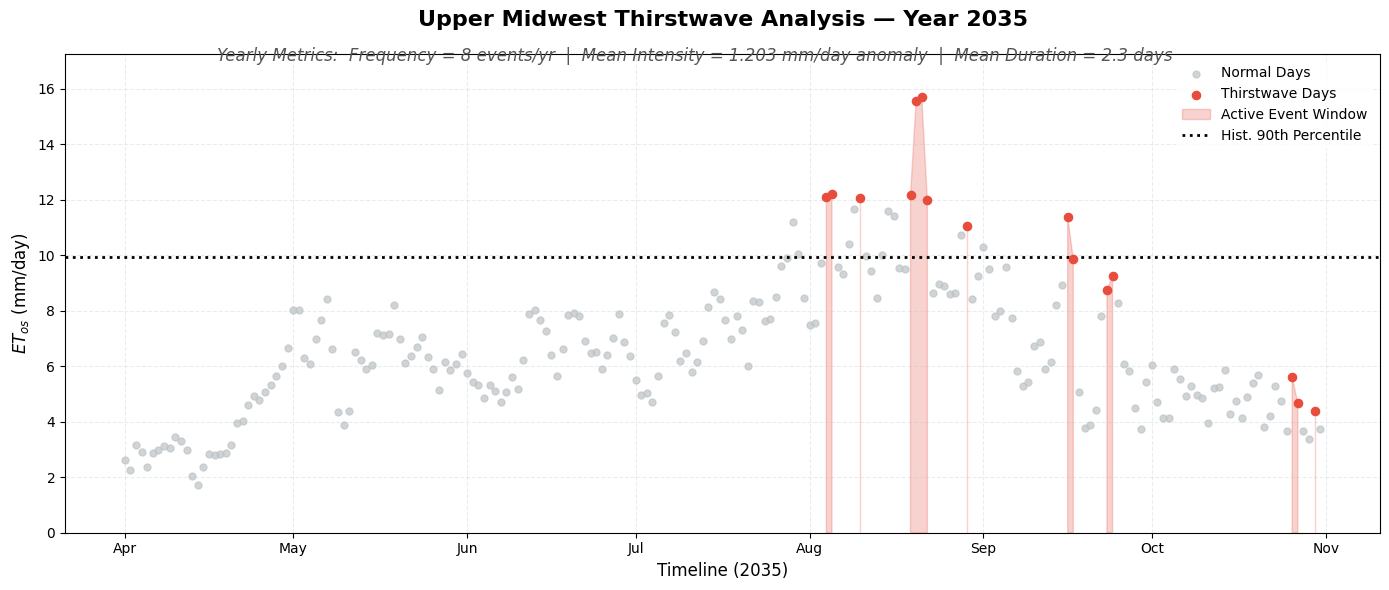

In [9]:
def plot_thirstwave_single_year(future_ds, hist_ds, target_year):
    """
    Plots a specific year from the future dataset as a scatter plot,
    highlighting active thirstwaves against the historical 90th percentile baseline.
    """
    # 1. Cleanly convert cftime to standard pandas datetime for the future dataset
    try:
        time_index = future_ds.indexes['time'].to_datetimeindex()
        future_ds = future_ds.assign_coords(time=time_index)
    except AttributeError:
        pass # Already standard datetime
        
    # 2. Filter dataset to the chosen target year
    yearly_ds = future_ds.sel(time=str(target_year))
    
    time = pd.to_datetime(yearly_ds['time'].values)
    et_os = yearly_ds['ET_os'].values
    is_tw = yearly_ds['is_thirstwave'].values
    
    # 3. Calculate Historical 90th Percentile Baseline
    hist_90th = float(hist_ds['ET_os'].quantile(0.90).values)
    
    # 4. Calculate Summary Metrics for this specific year
    # Frequency: Total unique event counts or the annual recorded frequency value
    mean_freq = yearly_ds['thirstwave_annual_frequency'].values[0]
    
    tw_days_mask = (is_tw == 1)
    if np.any(tw_days_mask):
        mean_intensity = yearly_ds['thirstwave_intensity'].values[tw_days_mask].mean()
        mean_duration = yearly_ds['thirstwave_duration'].values[tw_days_mask].mean()
    else:
        mean_intensity = 0.0
        mean_duration = 0.0

    # 5. Initialize the Plot
    fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
    
    # 6. Plot Data Points (Scatter)
    # Background baseline: days without a thirstwave (Grey)
    ax.scatter(time[~tw_days_mask], et_os[~tw_days_mask], 
               color='#bdc3c7', s=25, alpha=0.7, label='Normal Days')
    
    # Event days: active thirstwave days (Red)
    ax.scatter(time[tw_days_mask], et_os[tw_days_mask], 
               color='#e74c3c', s=35, zorder=3, label='Thirstwave Days')
    
    # 7. Highlight thirstwave regions using fill_between
    ax.fill_between(time, 0, et_os, where=tw_days_mask, 
                    color='#e74c3c', alpha=0.25, zorder=1, label='Active Event Window')
    
    # 8. Plot the historical 90th percentile threshold line
    ax.axhline(y=hist_90th, color='black', linestyle=':', linewidth=2, 
               zorder=2, label='Hist. 90th Percentile')
    
    # 9. Styling and Labels
    ax.set_title(f"Upper Midwest Thirstwave Analysis — Year {target_year}", fontsize=16, pad=20, weight='bold')
    
    subtitle_text = (f"Yearly Metrics:  "
                     f"Frequency = {mean_freq:.0f} events/yr  |  "
                     f"Mean Intensity = {mean_intensity:.3f} mm/day anomaly  |  "
                     f"Mean Duration = {mean_duration:.1f} days")
    
    fig.text(0.5, 0.89, subtitle_text, ha='center', fontsize=12, color='#555555', style='italic')
    
    ax.set_ylabel("$ET_{os}$ (mm/day)", fontsize=12)
    ax.set_xlabel(f"Timeline ({target_year})", fontsize=12)
    
    # Format X-Axis for a single year view (showing months clearly)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.xticks(rotation=0)
    
    ax.grid(True, linestyle='--', alpha=0.3, color='#bdc3c7')
    ax.set_ylim(0, max(np.max(et_os), hist_90th) * 1.1)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    plt.tight_layout()
    return fig, ax

# --- Example Execution Call ---

# Choose the exact year you want to visualize
CHOSEN_YEAR = 2035  

fig, ax = plot_thirstwave_single_year(ssp_detailed_ds, hist_detailed_ds, target_year=CHOSEN_YEAR)
plt.savefig(f"/data1/michsh/txt_files/thirstwave_timeline_{CHOSEN_YEAR}.png", bbox_inches='tight')
plt.show()

# CONUS PLOTTING

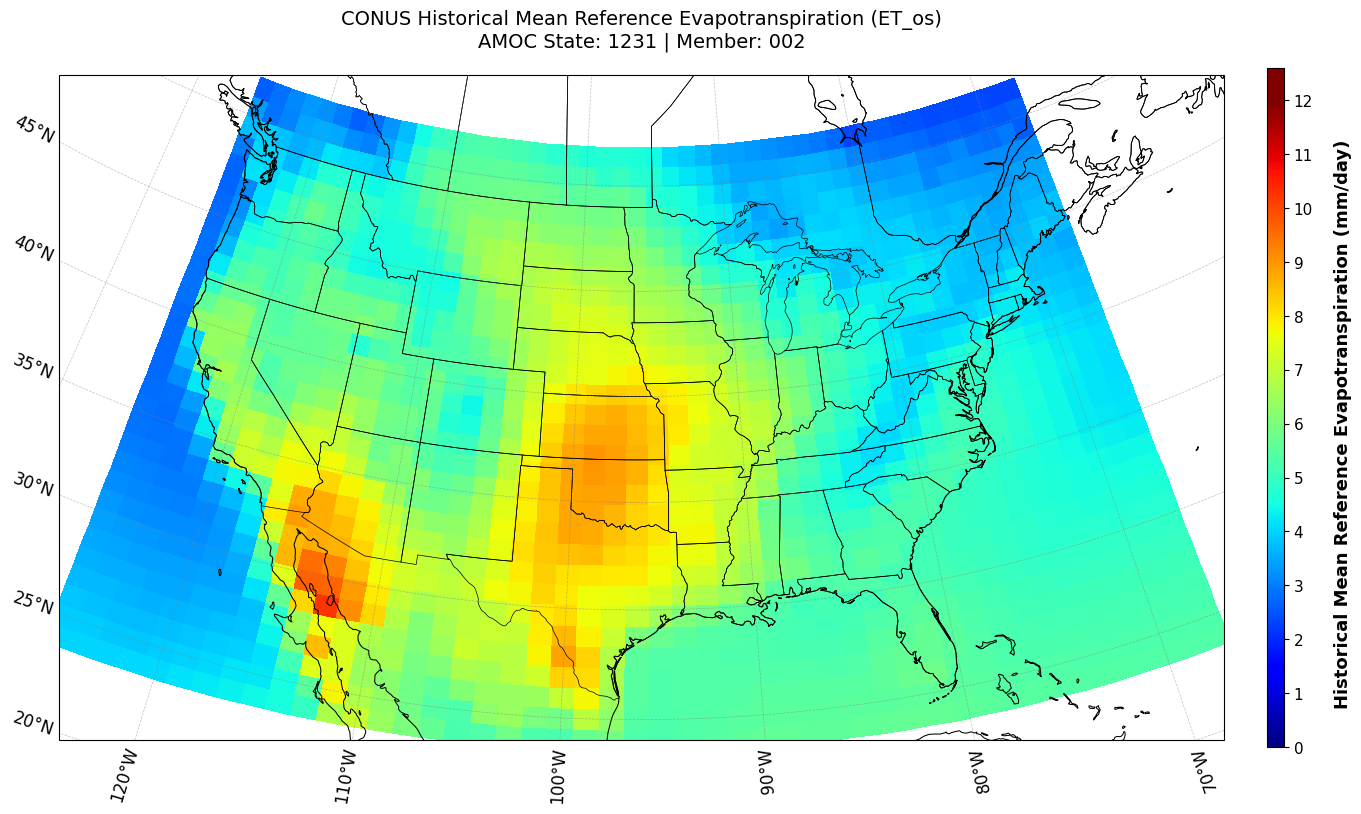

In [8]:
# Bounding box matching the Lambert Conformal format
crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

# Create the plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=crs)

# Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# Map features
ax.coastlines('50m', linewidth=0.75)
states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# Calculate ticks based on data
data_max = float(hist_mean.max())
max_even = int(np.ceil(data_max / 2) * 2)
tick_step = 1
custom_ticks = list(range(0, max_even + 1, tick_step))

# Render the background ET_os color fill
im = hist_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', 
                            add_colorbar=False, vmin=0.0, vmax=max_even, robust=True)

# Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                  color='gray', alpha=0.5, linestyle='--')

# Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black'}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Optional: Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# Changed orientation to 'vertical', moved pad/shrink parameters to fit the right side nicely
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                  aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

# Rotated the label back to vertical format
cb.set_label('Historical Mean Reference Evapotranspiration (mm/day)', size=13, weight='bold', labelpad=15)
cb.ax.tick_params(labelsize=11)

plt.title(f"CONUS Historical Mean Reference Evapotranspiration (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Define the plot bounds 
s_lat = 24.031413612565444
n_lat = 51.361256544502616
w_lon = -125
e_lon = -67

# Bound for the upper midwest, or the subplot within the larger CONUS plot
sub_s_lat = 39.109947643979055
sub_n_lat = 48.53403141361257
sub_w_lon = -104
sub_e_lon = -89

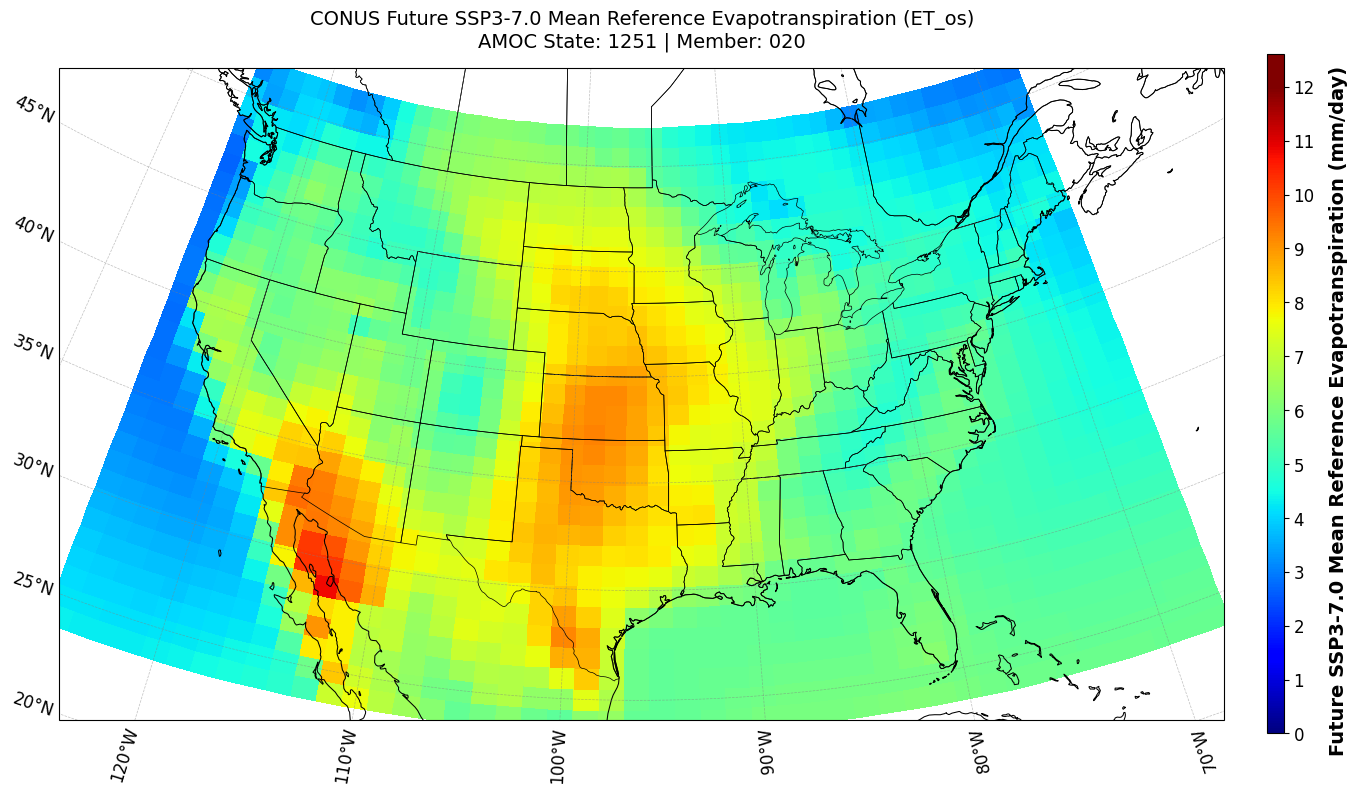

In [117]:
# Bounding box matching the Lambert Conformal format
crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

# Create the plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=crs)

# Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# Map features
ax.coastlines('50m', linewidth=0.75)
states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# Calculate ticks based on data
data_max = float(ftr_mean.max())
max_even = int(np.ceil(data_max / 2) * 2)
tick_step = 1
custom_ticks = list(range(0, max_even + 1, tick_step))

# 4. Render the background ET_os color fill
# IMPORTANT: Set vmax=max_even so the colorbar stretching matches your ticks perfectly
im = ftr_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', 
                        add_colorbar=False, vmin=0.0, vmax=max_even, robust=True)

# Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                  color='gray', alpha=0.5, linestyle='--')

# Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black'}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Optional: Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# Changed orientation to 'vertical', moved pad/shrink parameters to fit the right side nicely
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                  aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

# Colorbar label settings
cb.set_label('Future SSP3-7.0 Mean Reference Evapotranspiration (mm/day)', size=14, weight='bold', labelpad=10)
cb.ax.tick_params(labelsize=12)

plt.title(f"CONUS Future SSP3-7.0 Mean Reference Evapotranspiration (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

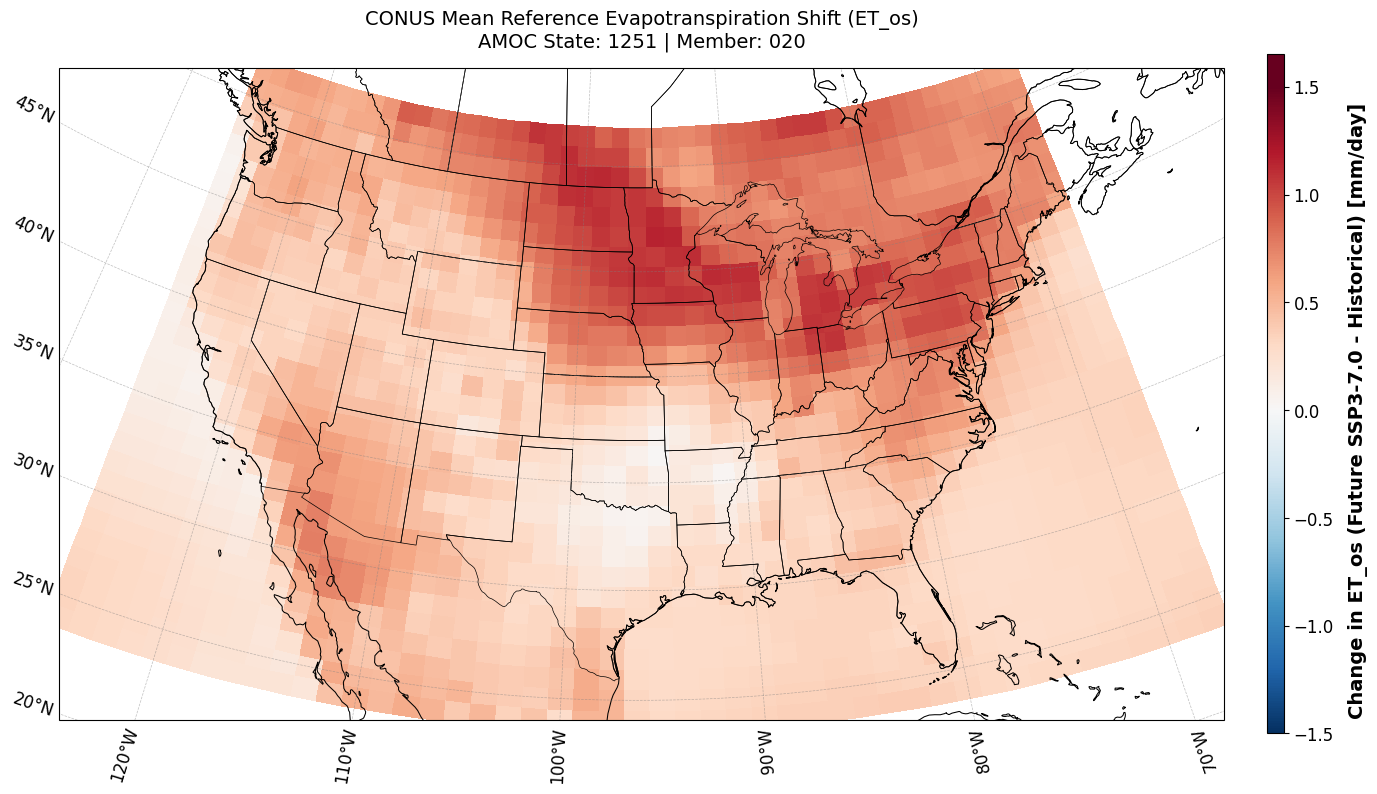

In [118]:
# Bounding box matching the Lambert Conformal format
crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

# Create the plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=crs)

# Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# Map features
ax.coastlines('50m', linewidth=0.75)
states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# --- FIX 1: DYNAMIC SYMMETRIC RANGE SELECTION ---
# Find the absolute maximum deviation from zero (negative or positive)
abs_max = max(abs(float(delta_mean.min())), abs(float(delta_mean.max())))

# Determine a clean rounding step. Evapotranspiration changes are typically small fractions,
# so step sizes of 0.2, 0.5, or 1.0 usually look best. 
# Let's dynamically find a clean limit based on how large your change values are:
if abs_max <= 1.0:
    vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2 (e.g., 0.2, 0.4, 0.6...)
    tick_step = 0.2
elif abs_max <= 2.5:
    vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5 (e.g., 0.5, 1.0, 1.5...)
    tick_step = 0.5
else:
    vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer (e.g., 3.0, 4.0...)
    tick_step = 1.0

vmin = -vmax

# --- FIX 2: CREATE SYMMETRIC TICKS ---
# Generates numbers from -vmax to +vmax stepping cleanly across zero
# We add tick_step * 0.5 to make sure the endpoint isn't clipped due to floating point precision
custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

# --- FIX 3: RENDER WITH BALANCED LIMITS ---
# Setting both vmin AND vmax forces the white color in 'RdBu_r' to land exactly on 0
im = delta_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

# Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                  color='gray', alpha=0.5, linestyle='--')

# Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black'}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Optional: Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# Changed orientation to 'vertical', moved pad/shrink parameters to fit the right side nicely
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                  aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

# Colorbar label settings
cb.set_label('Change in ET_os (Future SSP3-7.0 - Historical) [mm/day]', size=14, weight='bold', labelpad=10)
cb.ax.tick_params(labelsize=12)

# Dynamic Title
plt.title(f"CONUS Mean Reference Evapotranspiration Shift (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

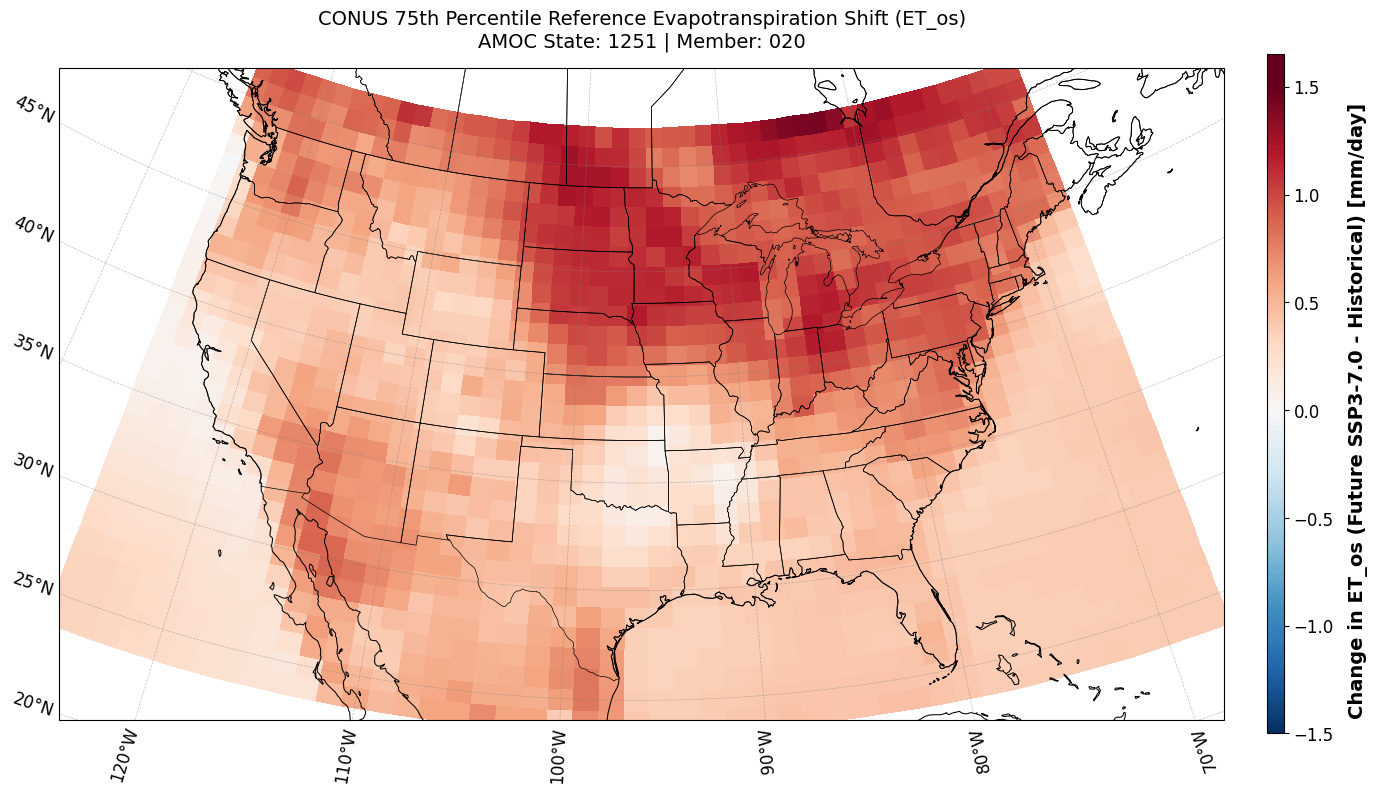

In [119]:
# Bounding box matching the Lambert Conformal format
crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

# Create the plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=crs)

# Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# Map features
ax.coastlines('50m', linewidth=0.75)
states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# --- FIX 1: DYNAMIC SYMMETRIC RANGE SELECTION ---
# Find the absolute maximum deviation from zero (negative or positive)
abs_max = max(abs(float(delta_75th.min())), abs(float(delta_75th.max())))

# Determine a clean rounding step. Evapotranspiration changes are typically small fractions,
# so step sizes of 0.2, 0.5, or 1.0 usually look best. 
# Let's dynamically find a clean limit based on how large your change values are:
if abs_max <= 1.0:
    vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2 (e.g., 0.2, 0.4, 0.6...)
    tick_step = 0.2
elif abs_max <= 2.5:
    vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5 (e.g., 0.5, 1.0, 1.5...)
    tick_step = 0.5
else:
    vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer (e.g., 3.0, 4.0...)
    tick_step = 1.0

vmin = -vmax

# --- FIX 2: CREATE SYMMETRIC TICKS ---
# Generates numbers from -vmax to +vmax stepping cleanly across zero
# We add tick_step * 0.5 to make sure the endpoint isn't clipped due to floating point precision
custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

# --- FIX 3: RENDER WITH BALANCED LIMITS ---
# Setting both vmin AND vmax forces the white color in 'RdBu_r' to land exactly on 0
im = delta_75th.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

# Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                  color='gray', alpha=0.5, linestyle='--')

# Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black'}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Optional: Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# Changed orientation to 'vertical', moved pad/shrink parameters to fit the right side nicely
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                  aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

# Colorbar label settings
cb.set_label('Change in ET_os (Future SSP3-7.0 - Historical) [mm/day]', size=14, weight='bold', labelpad=10)
cb.ax.tick_params(labelsize=12)

# Dynamic Title
plt.title(f"CONUS 75th Percentile Reference Evapotranspiration Shift (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

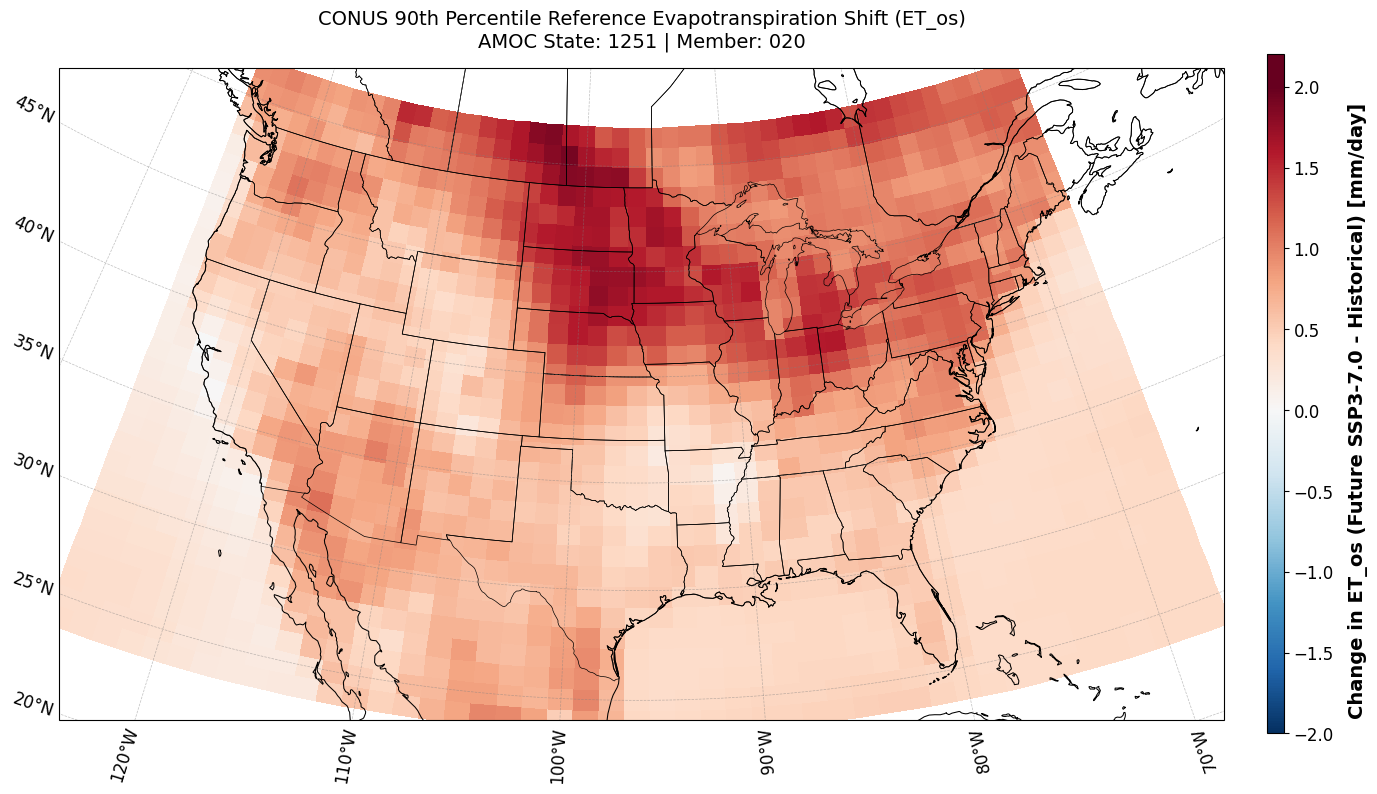

In [120]:
# Bounding box matching the Lambert Conformal format
crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

# Create the plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=crs)

# Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# Map features
ax.coastlines('50m', linewidth=0.75)
states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# --- FIX 1: DYNAMIC SYMMETRIC RANGE SELECTION ---
# Find the absolute maximum deviation from zero (negative or positive)
abs_max = max(abs(float(delta_90th.min())), abs(float(delta_90th.max())))

# Determine a clean rounding step. Evapotranspiration changes are typically small fractions,
# so step sizes of 0.2, 0.5, or 1.0 usually look best. 
# Let's dynamically find a clean limit based on how large your change values are:
if abs_max <= 1.0:
    vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2 (e.g., 0.2, 0.4, 0.6...)
    tick_step = 0.2
elif abs_max <= 2.5:
    vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5 (e.g., 0.5, 1.0, 1.5...)
    tick_step = 0.5
else:
    vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer (e.g., 3.0, 4.0...)
    tick_step = 1.0

vmin = -vmax

# --- FIX 2: CREATE SYMMETRIC TICKS ---
# Generates numbers from -vmax to +vmax stepping cleanly across zero
# We add tick_step * 0.5 to make sure the endpoint isn't clipped due to floating point precision
custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

# --- FIX 3: RENDER WITH BALANCED LIMITS ---
# Setting both vmin AND vmax forces the white color in 'RdBu_r' to land exactly on 0
im = delta_90th.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

# Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                  color='gray', alpha=0.5, linestyle='--')

# Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black'}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Optional: Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# Changed orientation to 'vertical', moved pad/shrink parameters to fit the right side nicely
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                  aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

# Colorbar label settings
cb.set_label('Change in ET_os (Future SSP3-7.0 - Historical) [mm/day]', size=14, weight='bold', labelpad=10)
cb.ax.tick_params(labelsize=12)

# Dynamic Title
plt.title(f"CONUS 90th Percentile Reference Evapotranspiration Shift (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

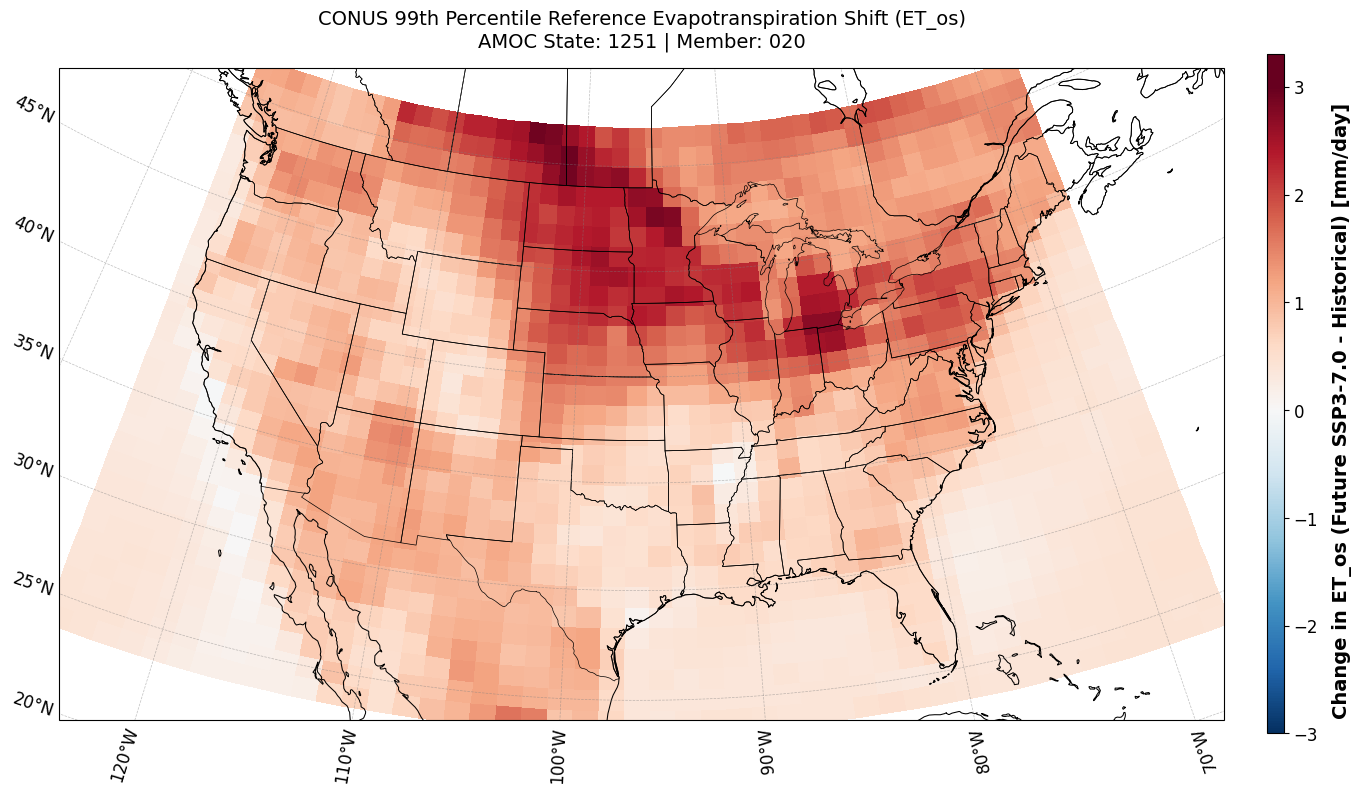

In [121]:
# Bounding box matching the Lambert Conformal format
crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

# Create the plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=crs)

# Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# Map features
ax.coastlines('50m', linewidth=0.75)
states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# --- FIX 1: DYNAMIC SYMMETRIC RANGE SELECTION ---
# Find the absolute maximum deviation from zero (negative or positive)
abs_max = max(abs(float(delta_99th.min())), abs(float(delta_99th.max())))

# Determine a clean rounding step. Evapotranspiration changes are typically small fractions,
# so step sizes of 0.2, 0.5, or 1.0 usually look best. 
# Let's dynamically find a clean limit based on how large your change values are:
if abs_max <= 1.0:
    vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2 (e.g., 0.2, 0.4, 0.6...)
    tick_step = 0.2
elif abs_max <= 2.5:
    vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5 (e.g., 0.5, 1.0, 1.5...)
    tick_step = 0.5
else:
    vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer (e.g., 3.0, 4.0...)
    tick_step = 1.0

vmin = -vmax

# --- FIX 2: CREATE SYMMETRIC TICKS ---
# Generates numbers from -vmax to +vmax stepping cleanly across zero
# We add tick_step * 0.5 to make sure the endpoint isn't clipped due to floating point precision
custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

# --- FIX 3: RENDER WITH BALANCED LIMITS ---
# Setting both vmin AND vmax forces the white color in 'RdBu_r' to land exactly on 0
im = delta_99th.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

# Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                  color='gray', alpha=0.5, linestyle='--')

# Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black'}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Optional: Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 56, 5))

# Changed orientation to 'vertical', moved pad/shrink parameters to fit the right side nicely
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                  aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

# Colorbar label settings
cb.set_label('Change in ET_os (Future SSP3-7.0 - Historical) [mm/day]', size=14, weight='bold', labelpad=10)
cb.ax.tick_params(labelsize=12)

# Dynamic Title
plt.title(f"CONUS 99th Percentile Reference Evapotranspiration Shift (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [122]:
# I would like to define how often the 75, 90th etc percentile happens within the dataset. Then I want to see how it shifts throughout the country on average. 

# Most importantly is the 90th percentile. Lets define that and store it as a txt file. 

# I want to take the data from these plots and put it all into a txt file. For each coordinate I want  value of avg_delta, avg_hist, avg_ftr of ET_os.
# Then I can combine x amount of seemble members by lat and lon, take the average of each value, and then plot the averages of all the members for the hsit, ftr, and delta periods. 

# need to make a code that looks through the entire dataset of the upper midwest. This code will then take the average 

frequency = []
intencity = []
duration = []

# Look at the entire 250yr dataset 
# determine the 90th percentile of ETos for the historic period for the TIME SPAN of a year
    # The growing period is definded form April 1st to OCtober 31st
    # Find the 90th percentile of data for every day within that 214 day span across every year of the dataset. 
    # Combine values of ET_os based on date time of month/day
# Once the historical 90th percentile line is drawn across the entire dataset it should fluctuate every day and represent a seasonal 90th percentile of ET_os
# With this 90th percentile line I can then evaluate thirstwave frequency, intencity, and duration for the historic dataset
    # 1. This requires looking through every year of the 150 yr dataset and finding days that 1. Thirstwave intensity: mean magnitude of ETos anomaly (relative to the 90th percentile threshold) across all
    #days that belong to thirstwaves detected during the growing season. Thirstwave intensity isreported as mm d− 1
    #for simplicity, but it is important to note the distinction between ETos units (mm d− 1) and intensity units (mmd− 1 above the 90th percentile), the latter being an anomaly.
    #2. Thirstwave duration: The mean length (in days) of all thirstwaves detected during the growing season.
    #3. Thirstwave frequency: The total number of thirstwaves (discrete events) detected during the growing season.
    # Then I will append these values for each year into the frequency, intencity, duration list and average how many thristwaves occur within this period. 
    # With this baseline we can use the same formla to evaluate the future period and see how thristwaves will change over time based on hsitoricl trends.
    

In [48]:
# # =====================================================================
# # SAVE TO SINGULAR ZARR STORE (Replaces the text file export)
# # =====================================================================

# # 1. Combine your computed 2D map grids into a single Xarray Dataset
# member_ds = xr.Dataset({
#     'avg_hist': hist_spatial_slice,  # Your historical time-mean map
#     'avg_ftr': ftr_spatial_slice,   # Your future SSP time-mean map
#     'avg_delta': delta               # Your calculated change map (Future - Hist)
# })

# # 2. Attach the current member ID as metadata so Xarray can track it later
# member_ds = member_ds.assign_coords(member=desired_ensemble_member)

# # 3. Define the output file path using your existing variables
# zarr_output_path = f"/data1/michsh/zarr_outputs/{desired_AMOC_state}/ZARR_{desired_AMOC_state}_{desired_ensemble_member}.zarr"

# # 4. Save to its own standalone Zarr directory
# member_ds.to_zarr(zarr_output_path, mode='w')

# print(f"SUCCESS: Singular Zarr file safely saved to {zarr_output_path}")

In [49]:
ds = xr.open_dataset(f'/data1/michsh/zarr_outputs/{desired_AMOC_state}/spatial_member_{desired_ensemble_member}.zarr', engine='zarr')
ds

<xarray.Dataset> Size: 16kB
Dimensions:    (lat: 28, lon: 47)
Coordinates:
  * lat        (lat) float64 224B 24.03 24.97 25.92 26.86 ... 47.59 48.53 49.48
  * lon        (lon) float64 376B 235.0 236.2 237.5 238.8 ... 290.0 291.2 292.5
    member     <U3 12B ...
Data variables:
    avg_delta  (lat, lon) float32 5kB ...
    avg_ftr    (lat, lon) float32 5kB ...
    avg_hist   (lat, lon) float32 5kB ...

In [50]:
ds_var = ds['avg_delta']
ds_var

<xarray.DataArray 'avg_delta' (lat: 28, lon: 47)> Size: 5kB
[1316 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 224B 24.03 24.97 25.92 26.86 ... 47.59 48.53 49.48
  * lon      (lon) float64 376B 235.0 236.2 237.5 238.8 ... 290.0 291.2 292.5
    member   <U3 12B ...

In [51]:
# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import matplotlib.ticker as mticker

# # =====================================================================
# # 1. LOAD THE READY-TO-PLOT DATA FROM ZARR
# # =====================================================================
# desired_AMOC_state = '1251'
# desired_ensemble_member = '002' # Or whichever member you want to plot

# # Pull the specific variable out of the Zarr dataset
# # (Options: 'avg_hist', 'avg_ftr', or 'avg_delta')
# delta = ds['avg_delta']

# # Extract geographic boundaries directly from the saved coordinates
# w_lon, e_lon = float(delta['lon'].min()), float(delta['lon'].max())
# s_lat, n_lat = float(delta['lat'].min()), float(delta['lat'].max())

# # If your saved lon coordinates are in 0-360 system, convert the limits 
# # back to -180 to 180 for Cartopy's set_extent function
# if w_lon > 180: w_lon -= 360
# if e_lon > 180: e_lon -= 360

# # =====================================================================
# # 2. YOUR EXACT PLOTTING CODE (UNCHANGED)
# # =====================================================================
# # Bounding box matching the Lambert Conformal format
# crs = ccrs.LambertConformal(central_longitude=-100, central_latitude=35, standard_parallels=(30, 60))

# fig = plt.figure(figsize=(15, 10))
# ax = plt.axes(projection=crs)
# ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

# # Map features
# ax.coastlines('50m', linewidth=0.75)
# states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
# ax.add_feature(states, edgecolor='black', linewidth=0.5)

# # --- DYNAMIC SYMMETRIC RANGE SELECTION ---
# abs_max = max(abs(float(delta.min())), abs(float(delta.max())))
# if abs_max <= 1.0:
#     vmax = np.ceil(abs_max * 5) / 5  
#     tick_step = 0.2
# elif abs_max <= 2.5:
#     vmax = np.ceil(abs_max * 2) / 2  
#     tick_step = 0.5
# else:
#     vmax = float(np.ceil(abs_max))   
#     tick_step = 1.0
# vmin = -vmax

# custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

# # Render background fill directly using your loaded Zarr variable
# im = delta.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
#                 add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

# # Gridlines
# gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
#                   color='gray', alpha=0.5, linestyle='--')
# gl.top_labels, gl.right_labels = False, False
# gl.bottom_labels, gl.left_labels = True, True
# gl.x_inline, gl.y_inline = False, False
# gl.xlabel_style = gl.ylabel_style = {'size': 12, 'color': 'black'}
# gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
# gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# # Colorbar
# cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
#                   aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 
# cb.set_label('Change in Reference Evapotranspiration (Future SSP3-7.0 - Historical) [mm/day]', size=14, weight='bold', labelpad=10)
# cb.ax.tick_params(labelsize=12)

# plt.title(f"CONUS Reference Evapotranspiration Shift (ET_os)\nAMOC State: {desired_AMOC_state} | Member: {desired_ensemble_member}", fontsize=14, pad=15)
# plt.tight_layout()
# plt.show()

In [52]:
# import numpy as np
# import xarray as xr
# import pandas as pd
# from scipy.ndimage import label

# # 1. Open the Zarr store (Lazy loading: takes milliseconds!)
# zarr_path = "/data1/michsh/zarr_files/1251/MIDWEST_CONUS_1251.zarr"
# ds = xr.open_zarr(zarr_path, consolidated=True)

# # 2. Separate into Historical and Future blocks based on the time dimension
# # Adjust years based on your dataset limits (e.g., historical ends in 2014)
# hist_ds = ds.sel(time=slice(None, "2014-12-31"))
# ssp_ds = ds.sel(time=slice("2015-01-01", None))

# # 3. Calculate the daily 90th percentile baseline threshold using ALL historical data
# # We can pool all ensemble members or average across them to build a highly robust threshold.
# historical_threshold = hist_ds['ET_os'].groupby("time.dayofyear").quantile(0.9, dim=["time", "ensemble_member"])

# # 4. Integrate your thirstwave logic function from before
# def analyze_thirstwaves(ds_array, threshold_series):
#     """
#     Analyzes an xarray DataArray for thirstwave metrics across members and years.
#     """
#     members = ds_array['ensemble_member'].values
#     records = []
    
#     for member in members:
#         member_ds = ds_array.sel(ensemble_member=member)['ET_os']
#         years = np.unique(member_ds["time.year"].values)
        
#         for year in years:
#             year_ds = member_ds.sel(time=str(year))
            
#             # Slice for Growing Season (April 1 to October 31)
#             growing_season = year_ds.where(
#                 (year_ds["time.month"] >= 4) & (year_ds["time.month"] <= 10), drop=True
#             ).load() # Load just this single year chunk into memory
            
#             if len(growing_season) == 0:
#                 continue
                
#             day_of_years = np.clip(growing_season["time.dayofyear"].values, 1, 365)
#             year_threshold = threshold_series.sel(dayofyear=day_of_years).values
            
#             # Anomaly & Mask
#             anomaly = growing_season.values - year_threshold
#             exceeded_mask = anomaly > 0
            
#             labeled_events, num_features = label(exceeded_mask)
            
#             if num_features == 0:
#                 records.append({'Member': member, 'Year': year, 'Frequency': 0, 'Intensity': 0, 'Duration': 0})
#                 continue
                
#             event_durations = [np.sum(labeled_events == i) for i in range(1, num_features + 1)]
#             event_intensities = [np.mean(anomaly[labeled_events == i]) for i in range(1, num_features + 1)]
            
#             records.append({
#                 'Member': member,
#                 'Year': year,
#                 'Frequency': num_features,
#                 'Intensity': np.mean(event_intensities),
#                 'Duration': np.mean(event_durations)
#             })
            
#     return pd.DataFrame(records)

# # 5. Run the calculations efficiently
# print("Analyzing historical thirstwaves...")
# df_hist_metrics = analyze_thirstwaves(hist_ds, historical_threshold)

# print("Analyzing future thirstwaves...")
# df_ssp_metrics = analyze_thirstwaves(ssp_ds, historical_threshold)

# # Save final tabular metrics to a small CSV for final plotting
# df_hist_metrics.to_csv("/data1/michsh/txt_files/1251/historical_thirstwave_summary.csv", index=False)
# df_ssp_metrics.to_csv("/data1/michsh/txt_files/1251/ssp_thirstwave_summary.csv", index=False)
# print("Finished! Ready to build trends and boxplots.")

In [ ]:
import numpy as np
import xarray as xr
from scipy.ndimage import label

# --- Assumptions from your setup ---
# ds_subregion: xarray.DataArray of ET_os for the Upper Midwest (time, lat, lon)
# already sliced/weighted and averaged spatially to a 1D time series.

# 1. Ensure we only look at the time-series line (Spatially Averaged)
# Assuming `hist_zeroed_avg` from your previous script is a 1D time series (time,)
# Let's make sure it has a proper datetime index.

# 2. Compute the daily 90th percentile threshold across all years
# Grouping by month and day allows us to get a 90th percentile value for Jan 1, Jan 2, etc.
historical_threshold = hist_zeroed_avg.groupby("time.dayofyear").quantile(0.9, dim="time")

# 3. Define functions to calculate the metrics per year
def analyze_thirstwaves(ds_series, threshold_series):
    """
    Analyzes a 1D time series (one year or full dataset) for thirstwave metrics.
    """
    years = np.unique(ds_series["time.year"].values)
    
    annual_frequency = []
    annual_intensity = []
    annual_duration = []
    
    for year in years:
        # Slice for the current year
        year_ds = ds_series.sel(time=str(year))
        
        # Filter for Growing Season: April 1st (4/1) to October 31st (10/31)
        # April 1st is Day of Year ~91, Oct 31st is ~304 (shifts slightly on leap years)
        growing_season = year_ds.where(
            (year_ds Tint_index_time := year_ds["time.month"] >= 4) & (year_ds Tint_index_time := year_ds["time.month"] <= 10), 
            drop=True
        )
        
        if len(growing_season) == 0:
            continue
            
        # Get the threshold corresponding to each day's 'dayofyear' in the growing season
        # We broadcast the daily threshold to match the length of this specific year's growing season
        day_of_years = growing_season["time.dayofyear"].values
        # Handle cases where dayofyear might slightly map out of bounds due to leap years (e.g., day 366)
        day_of_years = np.clip(day_of_years, 1, 365) 
        year_threshold = threshold_series.sel(dayofyear=day_of_years).values
        
        # Calculate Anomaly
        et_values = growing_season.values
        anomaly = et_values - year_threshold
        
        # Binary mask where ET_os exceeds the 90th percentile
        exceeded_mask = anomaly > 0
        
        # Label consecutive days (discrete events)
        labeled_events, num_features = label(exceeded_mask)
        
        if num_features == 0:
            # No thirstwaves detected this growing season
            annual_frequency.append(0)
            annual_intensity.append(0)
            annual_duration.append(0)
            continue
            
        # Metrics for the current year
        event_durations = []
        event_intensities = []
        
        for event_id in range(1, num_features + 1):
            event_mask = (labeled_events == event_id)
            
            # Duration: total number of days for this specific event
            duration_days = np.sum(event_mask)
            event_durations.append(duration_days)
            
            # Intensity: mean magnitude of the anomaly during this event
            mean_intensity = np.mean(anomaly[event_mask])
            event_intensities.append(mean_intensity)
            
        # Append annual metrics (averaging the events within this specific year)
        annual_frequency.append(num_features)
        annual_intensity.append(np.mean(event_intensities))
        annual_duration.append(np.mean(event_durations))
        
    return annual_frequency, annual_intensity, annual_duration

# --- Run the Analysis ---
# 1. Historical Baseline
hist_freq, hist_int, hist_dur = analyze_thirstwaves(hist_zeroed_avg, historical_threshold)

# 2. Future Period (Evaluated against the SAME historical baseline threshold)
# Assuming `ssp_zeroed_avg` is your future time series
ssp_freq, ssp_int, ssp_dur = analyze_thirstwaves(ssp_zeroed_avg, historical_threshold)

print(f"Historical Mean Frequency: {np.mean(hist_freq):.2f} events/year")
print(f"Future Mean Frequency: {np.mean(ssp_freq):.2f} events/year")